Import et read du fichier

5 première lignes / Infos par colonnes

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv('../data/Dummy Data HSS.csv')

print(df.head())
print(df.info())

     TV      Radio  Social Media Influencer       Sales
0  16.0   6.566231      2.907983       Mega   54.732757
1  13.0   9.237765      2.409567       Mega   46.677897
2  41.0  15.886446      2.913410       Mega  150.177829
3  83.0  30.020028      6.922304       Mega  298.246340
4  15.0   8.437408      1.405998      Micro   56.594181
<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   str    
 4   Sales         4566 non-null   float64
dtypes: float64(4), str(1)
memory usage: 178.7 KB
None


Visuel du nombre de null par colonne

In [5]:
print(df.isnull().sum())

TV              10
Radio            4
Social Media     6
Influencer       0
Sales            6
dtype: int64


Supprime Sales vides

In [7]:
df = df.dropna(subset=["Sales"])
print(df.shape)

(4566, 5)


Vérif du reste

In [8]:
print(df.isnull().sum())

TV              10
Radio            4
Social Media     6
Influencer       0
Sales            0
dtype: int64


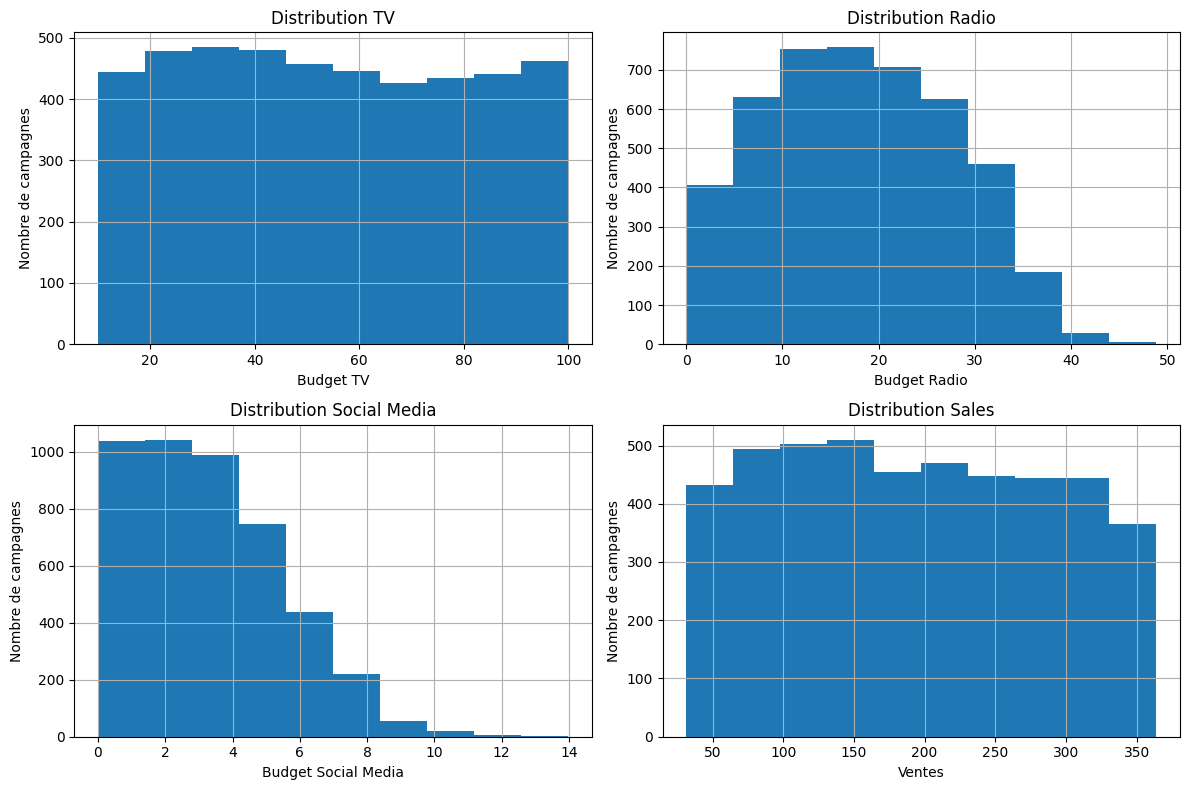

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df["TV"].hist(ax=axes[0, 0])
axes[0, 0].set_title("Distribution TV")
axes[0, 0].set_xlabel("Budget TV")
axes[0, 0].set_ylabel("Nombre de campagnes")

df["Radio"].hist(ax=axes[0, 1])
axes[0, 1].set_title("Distribution Radio")
axes[0, 1].set_xlabel("Budget Radio")
axes[0, 1].set_ylabel("Nombre de campagnes")

df["Social Media"].hist(ax=axes[1, 0])
axes[1, 0].set_title("Distribution Social Media")
axes[1, 0].set_xlabel("Budget Social Media")
axes[1, 0].set_ylabel("Nombre de campagnes")

df["Sales"].hist(ax=axes[1, 1])
axes[1, 1].set_title("Distribution Sales")
axes[1, 1].set_xlabel("Ventes")
axes[1, 1].set_ylabel("Nombre de campagnes")

plt.tight_layout()
plt.show()

Observations :

- TV : budgets répartis de manière assez régulière entre 10 et 100 → tous les niveaux de budget sont représentés
- Radio : beaucoup de campagnes entre 10 et 25 → budgets radio souvent moyens
- Social Media : beaucoup de campagnes entre 0 et 4 → budgets social media généralement faibles
- Sales : ventes réparties sur une large plage → variable cible exploitable pour l’analyse

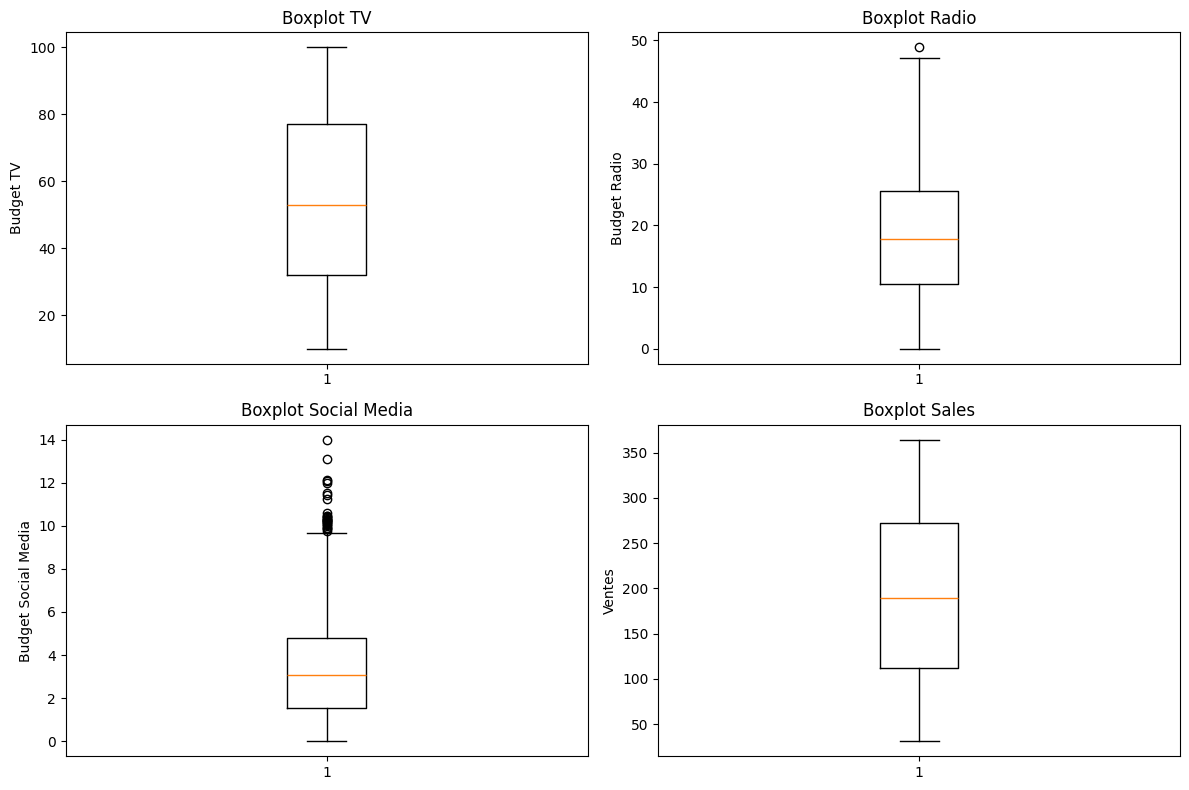

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].boxplot(df["TV"].dropna())
axes[0, 0].set_title("Boxplot TV")
axes[0, 0].set_ylabel("Budget TV")

axes[0, 1].boxplot(df["Radio"].dropna())
axes[0, 1].set_title("Boxplot Radio")
axes[0, 1].set_ylabel("Budget Radio")

axes[1, 0].boxplot(df["Social Media"].dropna())
axes[1, 0].set_title("Boxplot Social Media")
axes[1, 0].set_ylabel("Budget Social Media")

axes[1, 1].boxplot(df["Sales"].dropna())
axes[1, 1].set_title("Boxplot Sales")
axes[1, 1].set_ylabel("Ventes")

plt.tight_layout()
plt.show()

Observations :

- TV : valeurs bien réparties, pas d’outliers visibles → distribution stable

- Radio : quelques valeurs élevées (outliers) → certains budgets radio plus importants que la majorité

- Social Media : beaucoup d’outliers vers le haut → quelques campagnes avec des budgets bien plus élevés que la plupart

- Sales : distribution large sans outliers marqués → cohérente avec une variable cible exploitable

**Analyse relation Influenceur-Sales**

In [20]:
print(df["Influencer"].value_counts())

Influencer
Mega     1156
Micro    1152
Nano     1137
Macro    1121
Name: count, dtype: int64


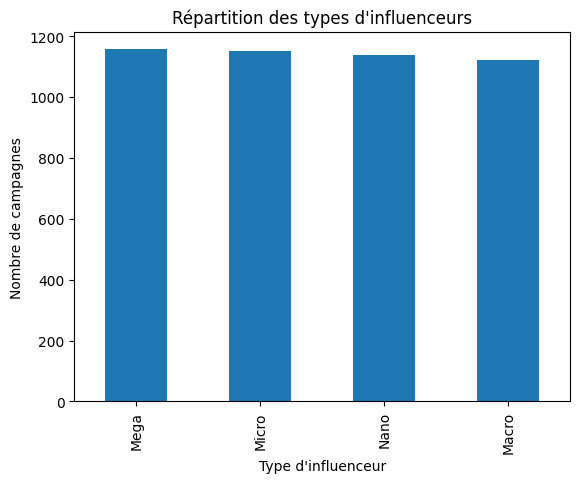

In [21]:
df["Influencer"].value_counts().plot(kind="bar")
plt.title("Répartition des types d'influenceurs")
plt.xlabel("Type d'influenceur")
plt.ylabel("Nombre de campagnes")
plt.show()

Observations :

- Les 4 types d’influenceurs (Mega, Micro, Nano, Macro) sont présents en quantités similaires
- Aucune catégorie ne domine 
- Répartition équilibrée des campagnes entre les types d’influenceurs

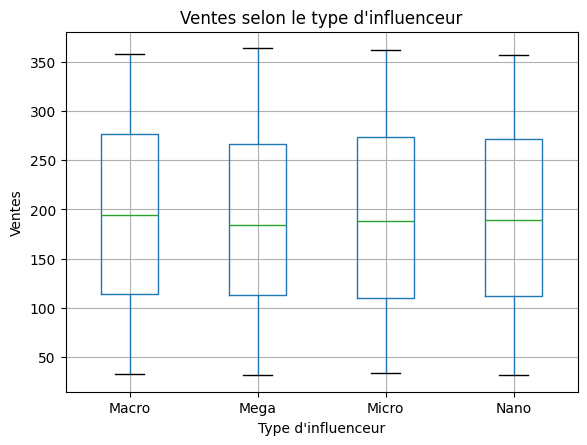

In [22]:
df.boxplot(column="Sales", by="Influencer")
plt.title("Ventes selon le type d'influenceur")
plt.suptitle("")
plt.xlabel("Type d'influenceur")
plt.ylabel("Ventes")
plt.show()

Observations :

- Les distributions de ventes sont très similaires pour tous les types d’influenceurs
- Les médianes sont proches → pas de différence marquée de performance
- Les plages de valeurs (min / max) sont équivalentes entre les catégories
- Aucun type d’influenceur ne se démarque clairement

Stats descriptives

In [9]:
print(df.describe())

                TV        Radio  Social Media        Sales
count  4556.000000  4562.000000   4560.000000  4566.000000
mean     54.068042    18.161617      3.325184   192.466602
std      26.116949     9.672827      2.212183    93.133092
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.553457      1.529879   112.322882
50%      53.000000    17.859513      3.056028   189.231172
75%      77.000000    25.651667      4.807356   272.507922
max     100.000000    48.871161     13.981662   364.079751


Correlation Budget et Sales

In [11]:
print(df[["TV", "Radio", "Social Media", "Sales"]].corr())

                    TV     Radio  Social Media     Sales
TV            1.000000  0.869265      0.527904  0.999497
Radio         0.869265  1.000000      0.607415  0.869105
Social Media  0.527904  0.607415      1.000000  0.528906
Sales         0.999497  0.869105      0.528906  1.000000


Relation TV-Sales

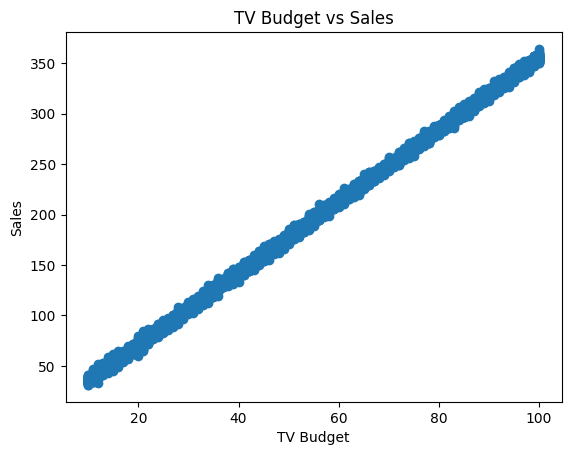

In [13]:
import matplotlib.pyplot as plt

plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.title("TV Budget vs Sales")
plt.show()

Conclusion : Augmentation budget TV = Augmentation Sales 
Relation linéaire avec une correlation 0.999

**Attention** : Peut être trop parfait

Relation Radio-Sales

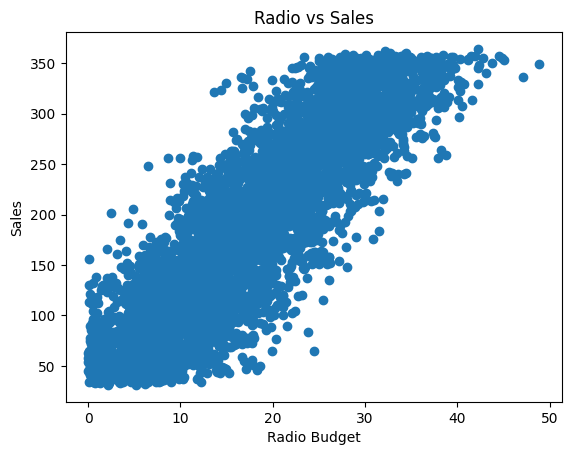

In [14]:
plt.scatter(df["Radio"], df["Sales"])
plt.xlabel("Radio Budget")
plt.ylabel("Sales")
plt.title("Radio vs Sales")
plt.show()

Conclusion : Augmentation du budget radio est aussi égale à une augmentation des ventes mais la relation entre les deux est beaucoup moins linéaire que celle avec TV donc moins d'influence avec une correlation de 0.869

Relation Social Media-Sales

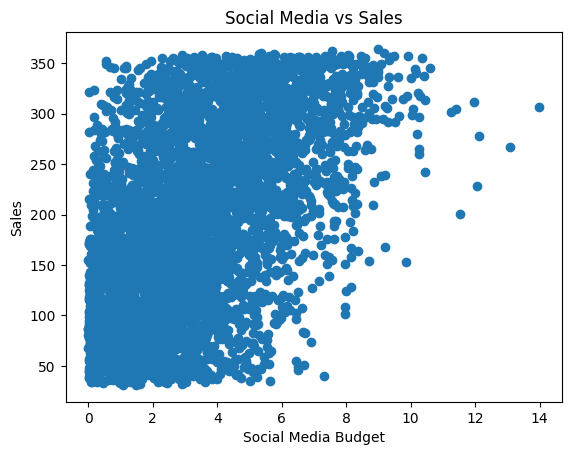

In [15]:
plt.scatter(df["Social Media"], df["Sales"])
plt.xlabel("Social Media Budget")
plt.ylabel("Sales")
plt.title("Social Media vs Sales")
plt.show()

Conclusion : Beaucoup plus dispersé la relation entre Social Media et Sales est beaucoup moins présente ce qui correspond bien à la correlation 0.528

Conclusion EDA :

L’analyse exploratoire met en évidence que les budgets marketing n’ont pas le même impact sur les ventes.

Le budget TV est le facteur le plus déterminant. Il présente une relation très forte et linéaire avec les ventes, ce qui en fait la variable la plus influente du modèle.

Le budget Radio montre également une relation positive avec les ventes, mais avec davantage de dispersion, ce qui indique une influence importante mais moins stable.

Le Social Media a un impact plus limité. La majorité des budgets sont faibles et la relation avec les ventes est plus diffuse, ce qui réduit son pouvoir explicatif.

Concernant la variable Influencer, les résultats montrent que les performances en termes de ventes sont similaires entre les différentes catégories. Aucun type d’influenceur ne se démarque clairement.

Enfin, les distributions des variables sont globalement cohérentes, sans anomalies majeures, bien que certaines valeurs élevées soient observées sur Social Media. Les données sont donc exploitables pour la modélisation.

En résumé, les ventes sont principalement expliquées par les budgets marketing, en particulier la TV, tandis que le type d’influenceur joue un rôle secondaire.